# NFXP — Original Dynamic Demand Model

**Oliver Ovdal Eiberg Jørgensen & Solveig Røndal-Liniger** — Dynamic Programming, Spring 2026

---

## Model

The consumer chooses each period $t$: $y_{it} \in \{0, 1, \ldots, J\}$ — either no purchase ($y=0$) or brand $j \in \{1,\ldots,J\}$.

**State variable:** $x_{it} = (\ell_{it},\, d_{it},\, e_t)$ where
- $\ell_{it}$: last-purchased brand
- $d_{it}$: time since last purchase
- $e_t$: promotion status (exogenous Markov chain)

**Utility (equation 1):**
$$U_{it} = \begin{cases}
  \alpha(\ell_{it}) - \beta^{\rm dep}(\ell_{it})\cdot d_{it} & \text{if } y_{it}=0 \\
  \alpha(j) - \gamma\cdot p_{it}(j) - \beta^{\rm sc}(\ell_{it},\, j) & \text{if } y_{it}=j
\end{cases}$$

- $\beta^{\rm dep}[\ell] \times d$: inventory depreciation linear in duration, rate is brand-specific
- $\gamma \cdot p_{it}(j)$: disutility from expenditure
- $\beta^{\rm sc}(\ell, j)$: brand switching cost

**Transition rule:**
$$
(\ell_{i,t+1},\, d_{i,t+1}) = \begin{cases}
  (\ell_{it},\, d_{it}+1) & \text{if } y_{it}=0 \\
  (j,\, 1) & \text{if } y_{it}=j
\end{cases}
$$

**Estimator:** NFXP (Rust 1987) — Nelder-Mead outer loop, VFI inner loop.

## 1. Import

In [15]:
# Standard library and scientific computing imports
import time
import numpy as np
import pandas as pd
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

## 2. Primitives and True Parameters

In [16]:
# ── Model dimensions ──────────────────────────────────────────────────────────
J     = 2       # number of brands
T     = 52      # periods per consumer
N     = 2_000   # consumers per panel
D_MAX = 10       # duration cap: d_idx ∈ {0,...,D_MAX}, paper-d ∈ {1,...,D_MAX+1}
DELTA = 0.95    # discount factor

# ── Price levels ──────────────────────────────────────────────────────────────
BASE_PRICES   = np.array([7.0, 10.0])   # regular unit prices
PROMO_DISC    = np.array([1.5,  2.0])   # promotion discount
PROMO_ENTRY   = 0.18                    # P(promotion starts)
PROMO_PERSIST = 0.62                    # P(promotion persists)

# ── True structural parameters (DGP) ─────────────────────────────────────────
#
#   u(0) = α(ℓ)  − β^dep[ℓ] · d
#   u(j) = α(j)  − γ · p(j) − β^sc(ℓ, j)
#
ALPHA_TRUE    = np.array([0.0,  0.50])          # α(1)=0 is the normalization
GAMMA_TRUE    = 0.05                             # marginal expenditure disutility
BETA_SC_TRUE  = np.array([[0.00, 0.30],          # β^sc[k,j]: switching cost k→j
                           [0.25, 0.00]])
BETA_DEP_TRUE = np.array([0.275, 0.275])         # β^dep[ℓ]: brand-specific depreciation rate

# ── Monte Carlo ───────────────────────────────────────────────────────────────
MC_REPS = 20
MC_SEED = 2024

# ── Choice indexing ───────────────────────────────────────────────────────────
# choice c = 0   → no purchase
# choice c = j   → buy brand j ∈ {1,...,J}
N_CHOICES = J + 1   # 3 choices: {0, 1, 2}

# ── Parameter vector ──────────────────────────────────────────────────────────
PARAM_NAMES = ["alpha_2", "gamma", "beta_sc_12", "beta_sc_21",
               "beta_dep_1", "beta_dep_2"]

THETA_TRUE = np.array([
    ALPHA_TRUE[1],
    GAMMA_TRUE,
    BETA_SC_TRUE[0, 1],
    BETA_SC_TRUE[1, 0],
    BETA_DEP_TRUE[0],
    BETA_DEP_TRUE[1],
])

print("True parameters:")
for n, v in zip(PARAM_NAMES, THETA_TRUE):
    print(f"  {n:<14} = {v}")
print(f"\nN_CHOICES={N_CHOICES}  |  BASE_PRICES={BASE_PRICES}  |  D_MAX={D_MAX}")

True parameters:
  alpha_2        = 0.5
  gamma          = 0.05
  beta_sc_12     = 0.3
  beta_sc_21     = 0.25
  beta_dep_1     = 0.275
  beta_dep_2     = 0.275

N_CHOICES=3  |  BASE_PRICES=[ 7. 10.]  |  D_MAX=10


## 3. Price Process — Hi-Lo (Assumption 2.1)

Promotion status $e_t \in \{0,1\}^J$ is a binary vector. With $J=2$ there are $2^2=4$ possible states. Brand promotions follow independent two-state Markov chains, and the joint transition probability is the product of the marginal probabilities.

In [17]:
# Enumerate all 2^J joint promotion states as binary vectors
promo_states = np.array(
    [[(s >> j) & 1 for j in range(J)] for s in range(2 ** J)], dtype=int
)
N_PROMO = len(promo_states)


def make_promo_transition() -> np.ndarray:
    # Build joint transition matrix as product of independent brand Markov chains
    trans = np.empty((N_PROMO, N_PROMO))
    for s, curr in enumerate(promo_states):
        prob_on = np.where(curr == 1, PROMO_PERSIST, PROMO_ENTRY)
        for sp, nxt in enumerate(promo_states):
            trans[s, sp] = np.prod(np.where(nxt == 1, prob_on, 1.0 - prob_on))
    return trans


PROMO_TRANS = make_promo_transition()

print("Unit prices by promotion state:")
for s, e in enumerate(promo_states):
    p = BASE_PRICES - PROMO_DISC * e
    print(f"  State {s}: e={tuple(e)}  p={p}")

Unit prices by promotion state:
  State 0: e=(0, 0)  p=[ 7. 10.]
  State 1: e=(1, 0)  p=[ 5.5 10. ]
  State 2: e=(0, 1)  p=[7. 8.]
  State 3: e=(1, 1)  p=[5.5 8. ]


## 4. Utility Function (equation 1)

$$U_{it} = \begin{cases}
  \alpha(\ell_{it}) - \beta^{\rm dep}[\ell_{it}] \cdot d_{it} & \text{if } y_{it}=0 \\
  \alpha(j) - \gamma\cdot p_{it}(j) - \beta^{\rm sc}(\ell_{it},\, j) & \text{if } y_{it}=j
\end{cases}$$

- $\gamma \cdot p_{it}(j)$: disutility from expenditure (linear in price)
- $\beta^{\rm dep}[\ell] \times d$: inventory depreciation linear in duration, rate is brand-specific
- $\beta^{\rm sc}(\ell, j)$: brand switching cost

In [18]:
def flow_util(choice, last_brand, duration, e_idx,
              alpha, gamma, beta_sc, beta_dep) -> float:
    """
    Deterministic period utility.

    choice    : 0 = no purchase; j ∈ {1,...,J} → buy brand j
    last_brand: ℓ ∈ {1,...,J}
    duration  : paper-d = d_idx + 1  ∈ {1,...,D_MAX+1}
    beta_dep  : (J,) array — brand-specific depreciation rate
    """
    l      = last_brand - 1
    prices = BASE_PRICES - PROMO_DISC * promo_states[e_idx]

    if choice == 0:
        # No purchase: inventory depreciates at brand-specific rate
        return alpha[l] - beta_dep[l] * duration

    j = choice - 1   # brand index (0-indexed)
    return alpha[j] - gamma * prices[j] - beta_sc[l, j]

## 5. Inner Loop: Value Function Iteration (VFI)

**State space:** $(\ell, d, e)$, $J \times (D_{\max}+1) \times N_e = 2 \times 4 \times 4 = 32$ states.

$V$ has shape `(J, D_MAX+1, N_PROMO)`.

Transition rules in VFI:
- No purchase: $(\ell, d_{\rm idx}) \to (\ell, \min(d_{\rm idx}+1, D_{\rm MAX}))$
- Purchase $j$: $(\ell, d_{\rm idx}) \to (j, 0)$ (paper-$d=1$)

In [19]:
def solve_vfi(alpha, gamma, beta_sc, beta_dep,
              tol: float = 1e-10, max_iter: int = 2_000) -> np.ndarray:
    """
    VFI for the original model (brand-specific β^dep).

    V shape: (J, D_MAX+1, N_PROMO).
    d_idx ∈ {0,...,D_MAX} corresponds to paper-d = d_idx + 1.
    """
    V = np.zeros((J, D_MAX + 1, N_PROMO))

    for _ in range(max_iter):
        # Expected continuation value (integrate over promotion process)
        EV = (V.reshape(J * (D_MAX + 1), N_PROMO) @ PROMO_TRANS.T
              ).reshape(J, D_MAX + 1, N_PROMO)

        V_new = np.empty_like(V)

        for l_idx in range(J):
            ell = l_idx + 1
            for d in range(D_MAX + 1):
                d_next = min(d + 1, D_MAX)   # d_idx for no purchase
                d_dur  = d + 1               # paper-d for the utility function
                for e in range(N_PROMO):
                    Q = np.empty(N_CHOICES)

                    # No purchase: state → (ℓ, d_next, e')
                    Q[0] = (flow_util(0, ell, d_dur, e, alpha, gamma, beta_sc, beta_dep)
                            + DELTA * EV[l_idx, d_next, e])

                    # Purchase brand j: state → (j, d_idx=0, e')  [paper d=1]
                    for j_idx in range(J):
                        Q[j_idx + 1] = (
                            flow_util(j_idx + 1, ell, d_dur, e, alpha, gamma, beta_sc, beta_dep)
                            + DELTA * EV[j_idx, 0, e]
                        )

                    # Log-sum-exp for the Emax (Gumbel extreme value assumption)
                    qm = Q.max()
                    V_new[l_idx, d, e] = qm + np.log(np.exp(Q - qm).sum())

        if np.max(np.abs(V_new - V)) < tol:
            return V_new
        V = V_new

    return V

## 6. Conditional Choice Probabilities (CCPs)

$$P(j \mid s;\theta) = \frac{\exp(Q_j)}{\sum_{k}\exp(Q_k)}, \quad Q_j = u(j, s) + \delta\cdot EV(\text{next state})$$

`P` shape: `(J, D_MAX+1, N_PROMO, N_CHOICES)`.

In [20]:
def compute_ccps(V, alpha, gamma, beta_sc, beta_dep) -> np.ndarray:
    """
    Compute CCPs from solved value function V.
    P shape: (J, D_MAX+1, N_PROMO, N_CHOICES).
    """
    # Expected continuation value integrated over next promotion state
    EV = (V.reshape(J * (D_MAX + 1), N_PROMO) @ PROMO_TRANS.T
          ).reshape(J, D_MAX + 1, N_PROMO)

    P = np.empty((J, D_MAX + 1, N_PROMO, N_CHOICES))

    for l_idx in range(J):
        ell = l_idx + 1
        for d in range(D_MAX + 1):
            d_next = min(d + 1, D_MAX)
            d_dur  = d + 1
            for e in range(N_PROMO):
                Q = np.empty(N_CHOICES)
                Q[0] = (flow_util(0, ell, d_dur, e, alpha, gamma, beta_sc, beta_dep)
                        + DELTA * EV[l_idx, d_next, e])
                for j_idx in range(J):
                    Q[j_idx + 1] = (
                        flow_util(j_idx + 1, ell, d_dur, e, alpha, gamma, beta_sc, beta_dep)
                        + DELTA * EV[j_idx, 0, e]
                    )
                # Softmax to get choice probabilities
                w = np.exp(Q - Q.max())
                P[l_idx, d, e, :] = w / w.sum()

    return P

## 7. Data Simulation

`simulate_panel` simulates a consumer panel from the model's CCPs and returns:
- `Y` ∈ {0,...,J}: brand choice (0 = no purchase)
- `L`: last-purchased brand (state variable)
- `D`: duration since last purchase, d_idx ∈ {0,...,D_MAX}
- `E_IDX`: promotion status

In [21]:
def _sample_rows(rng, row_probs: np.ndarray) -> np.ndarray:
    """Vectorized categorical draw: one observation per row of row_probs."""
    u = rng.random(len(row_probs))
    cumsum = np.cumsum(row_probs, axis=1)
    return (u[:, None] > cumsum).sum(axis=1)


def simulate_panel(P_true: np.ndarray,
                   n_consumers: int = N, n_periods: int = T,
                   seed=None) -> dict:
    """
    Simulate consumer panel from CCPs.
    P_true shape: (J, D_MAX+1, N_PROMO, N_CHOICES).

    Returns dict: Y, L, D, E_IDX — all (n_consumers, n_periods).
    """
    rng = np.random.default_rng(seed)

    # Pre-allocate arrays for the full panel
    Y     = np.zeros((n_consumers, n_periods), dtype=int)
    L     = np.zeros((n_consumers, n_periods), dtype=int)
    D     = np.zeros((n_consumers, n_periods), dtype=int)
    E_IDX = np.zeros((n_consumers, n_periods), dtype=int)

    # Random initial states
    ell   = rng.integers(1, J + 1,     size=n_consumers)
    dur   = rng.integers(0, D_MAX + 1, size=n_consumers)
    e_idx = rng.integers(0, N_PROMO,   size=n_consumers)

    for t in range(n_periods):
        # Record current state
        L[:, t]     = ell
        D[:, t]     = dur
        E_IDX[:, t] = e_idx

        # CCP lookup: state (ℓ-1, min(d,D_MAX), e)
        probs = P_true[ell - 1, np.minimum(dur, D_MAX), e_idx, :]
        y = _sample_rows(rng, probs)
        Y[:, t] = y

        # Update state variables (transition rule)
        bought = y > 0
        ell    = np.where(bought, y, ell)                      # new brand if purchased
        dur    = np.where(bought, 0, np.minimum(dur + 1, D_MAX))
        e_idx  = _sample_rows(rng, PROMO_TRANS[e_idx])

    return {"Y": Y, "L": L, "D": D, "E_IDX": E_IDX}

## 8. Log-Likelihood and NFXP

**Log-likelihood:**
$$\ell(\theta) = \sum_{i,t} \log P(y_{it} \mid \ell_{it}, d_{it}, e_{it}; \theta)$$

**NFXP (Rust 1987):** outer Nelder-Mead minimizes $-\ell(\theta)$; inner VFI solves the Bellman equation at each candidate $\theta$.

**Parameter vector:**
$$\theta = [\alpha_2,\; \gamma,\; \beta^{sc}_{12},\; \beta^{sc}_{21},\; \beta^{dep}_1,\; \beta^{dep}_2]$$

In [22]:
def log_likelihood(data: dict, P: np.ndarray) -> float:
    """Summed log-likelihood over all (i,t) observations."""
    Y, L, D, E = data["Y"], data["L"], data["D"], data["E_IDX"]
    probs = P[L - 1, D, E, Y]
    return float(np.sum(np.log(np.maximum(probs, 1e-300))))


def unpack(theta: np.ndarray):
    """Unpack theta = [alpha_2, gamma, beta_sc_12, beta_sc_21, beta_dep_1, beta_dep_2]."""
    alpha    = np.array([0.0, theta[0]])
    gamma    = float(theta[1])
    beta_sc  = np.array([[0.0, theta[2]], [theta[3], 0.0]])
    beta_dep = np.array([theta[4], theta[5]])   # (J,) brand-specific rates
    return alpha, gamma, beta_sc, beta_dep


def nfxp_objective(theta: np.ndarray, data: dict) -> float:
    # Solve VFI, compute CCPs, and return negative log-likelihood
    alpha, gamma, beta_sc, beta_dep = unpack(theta)
    V = solve_vfi(alpha, gamma, beta_sc, beta_dep)
    P = compute_ccps(V, alpha, gamma, beta_sc, beta_dep)
    return -log_likelihood(data, P)


def estimate_nfxp(data: dict, theta0: np.ndarray = None, verbose: bool = False):
    """Estimate the model with NFXP (Nelder-Mead)."""
    if theta0 is None:
        theta0 = np.array([0.1, 0.03, 0.3, 0.3, 0.2, 0.2])
    return minimize(
        fun=nfxp_objective,
        x0=theta0,
        args=(data,),
        method="Nelder-Mead",
        options={"maxiter": 10_000, "xatol": 1e-5, "fatol": 1e-5,
                 "disp": verbose, "adaptive": True},
    )

## 9. Pilot — Single Panel

Verify that VFI converges, the simulation looks reasonable, and that NFXP recovers the true parameters from a single panel.

In [23]:
print("Step 1: Solving DP at true parameters...")
a0, g0, sc0, dep0 = unpack(THETA_TRUE)
V_true = solve_vfi(a0, g0, sc0, dep0)
P_true = compute_ccps(V_true, a0, g0, sc0, dep0)
print("  VFI converged.")

print(f"\nStep 2: Simulating panel (N={N}, T={T})...")
data_pilot = simulate_panel(P_true, seed=42)
Y = data_pilot["Y"]
print(f"  No purchase: {(Y == 0).mean():.1%}")
for j in range(1, J + 1):
    print(f"  Brand {j}:     {(Y == j).mean():.1%}")

print("\nStep 3: Estimating with NFXP...")
# Perturb true parameters slightly as starting point
theta0_pilot = THETA_TRUE + np.array([0.05, 0.005, 0.05, 0.05, 0.02, 0.02])
t0 = time.perf_counter()
res_pilot = estimate_nfxp(data_pilot, theta0=theta0_pilot)
t1 = time.perf_counter() - t0
print(f"  Time: {t1:.1f}s  |  Converged: {res_pilot.success}  |  Iterations: {res_pilot.nit}")

print("\n" + "─" * 55)
df_pilot = pd.DataFrame({
    "Parameter": PARAM_NAMES,
    "True":      THETA_TRUE,
    "NFXP":      res_pilot.x,
    "Bias":      res_pilot.x - THETA_TRUE,
})
print(df_pilot.to_string(index=False, float_format=lambda x: f"{x:+.4f}"))

Step 1: Solving DP at true parameters...
  VFI converged.

Step 2: Simulating panel (N=2000, T=52)...
  No purchase: 34.7%
  Brand 1:     21.0%
  Brand 2:     44.3%

Step 3: Estimating with NFXP...
  Time: 92.8s  |  Converged: True  |  Iterations: 215

───────────────────────────────────────────────────────
 Parameter    True    NFXP    Bias
   alpha_2 +0.5000 +0.4988 -0.0012
     gamma +0.0500 +0.0504 +0.0004
beta_sc_12 +0.3000 +0.3384 +0.0384
beta_sc_21 +0.2500 +0.2391 -0.0109
beta_dep_1 +0.2750 +0.2796 +0.0046
beta_dep_2 +0.2750 +0.2780 +0.0030


## 10. Monte Carlo

For each replication:
1. Simulate a new panel from the DGP
2. Estimate the model with NFXP
3. Record estimates, bias, and RMSE

**Expected result:** low RMSE and bias close to zero for all 6 parameters.

In [24]:
def run_monte_carlo(n_reps: int = MC_REPS, seed: int = MC_SEED):
    rng_master = np.random.default_rng(seed)
    rep_seeds  = rng_master.integers(0, 1_000_000, size=n_reps)

    # Solve DP once at true parameters; all replications use the same DGP CCPs
    a_t, g_t, sc_t, dep_t = unpack(THETA_TRUE)
    V_t = solve_vfi(a_t, g_t, sc_t, dep_t)
    P_t = compute_ccps(V_t, a_t, g_t, sc_t, dep_t)

    print(f"MC  |  J={J}, T={T}, N={N}, D_MAX={D_MAX}, reps={n_reps}")
    print(f"DGP: β^dep={BETA_DEP_TRUE}\n")

    rows = []
    for rep in range(1, n_reps + 1):
        # Simulate a new panel for this replication
        data = simulate_panel(P_t, n_consumers=N, n_periods=T,
                              seed=int(rep_seeds[rep - 1]))

        # Random perturbation around true parameters as starting point
        rng_s  = np.random.default_rng(int(rep_seeds[rep - 1]) + 999)
        pert   = rng_s.normal(0, 0.05, size=6)
        theta0 = THETA_TRUE + pert

        t0 = time.perf_counter()
        r  = estimate_nfxp(data, theta0=theta0)
        t1 = time.perf_counter() - t0

        print(f"  Rep {rep:>3}/{n_reps}  conv={r.success}  ({t1:>4.0f}s)")

        for k, name in enumerate(PARAM_NAMES):
            rows.append({
                "rep":       rep,
                "param":     name,
                "true":      THETA_TRUE[k],
                "estimate":  r.x[k],
                "bias":      r.x[k] - THETA_TRUE[k],
                "sq_error":  (r.x[k] - THETA_TRUE[k]) ** 2,
                "converged": int(r.success),
            })

    # Aggregate bias, std, and RMSE across replications
    df = pd.DataFrame(rows)
    summary = pd.DataFrame([{
        "param":     name,
        "true":      THETA_TRUE[i],
        "mean_est":  df[df["param"] == name]["estimate"].mean(),
        "bias":      df[df["param"] == name]["bias"].mean(),
        "std":       df[df["param"] == name]["estimate"].std(ddof=1),
        "rmse":      np.sqrt(df[df["param"] == name]["sq_error"].mean()),
        "conv_rate": df[df["param"] == name]["converged"].mean(),
    } for i, name in enumerate(PARAM_NAMES)])

    return df, summary

In [25]:
# Run Monte Carlo and collect results and summary statistics
results, summary = run_monte_carlo()

MC  |  J=2, T=52, N=2000, D_MAX=10, reps=20
DGP: β^dep=[0.275 0.275]

  Rep   1/20  conv=True  ( 113s)
  Rep   2/20  conv=True  ( 116s)
  Rep   3/20  conv=True  (  91s)
  Rep   4/20  conv=True  ( 109s)
  Rep   5/20  conv=True  ( 128s)
  Rep   6/20  conv=True  ( 179s)
  Rep   7/20  conv=True  ( 126s)
  Rep   8/20  conv=True  ( 154s)
  Rep   9/20  conv=True  ( 136s)
  Rep  10/20  conv=True  (  90s)
  Rep  11/20  conv=True  ( 114s)
  Rep  12/20  conv=True  ( 135s)
  Rep  13/20  conv=True  ( 104s)
  Rep  14/20  conv=True  ( 114s)
  Rep  15/20  conv=True  ( 135s)
  Rep  16/20  conv=True  ( 112s)
  Rep  17/20  conv=True  ( 111s)
  Rep  18/20  conv=True  ( 129s)
  Rep  19/20  conv=True  ( 102s)
  Rep  20/20  conv=True  ( 123s)


## 11. Results

In [26]:
print("=" * 65)
print("NFXP Monte Carlo — original model (brand-specific β^dep)")
print(f"J={J}, T={T}, N={N}, D_MAX={D_MAX}, reps={MC_REPS}")
print("=" * 65)
print(summary.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

# Save results to CSV for reporting
results.to_csv("nfxp_mc_results_original.csv", index=False)
summary.to_csv("nfxp_mc_summary_original.csv", index=False)
print("\nSaved: nfxp_mc_results_original.csv  and  nfxp_mc_summary_original.csv")

NFXP Monte Carlo — original model (brand-specific β^dep)
J=2, T=52, N=2000, D_MAX=10, reps=20
     param   true  mean_est    bias    std   rmse  conv_rate
   alpha_2 0.5000    0.4811 -0.0189 0.0993 0.0986     1.0000
     gamma 0.0500    0.0500  0.0000 0.0015 0.0015     1.0000
beta_sc_12 0.3000   -0.0981 -0.3981 1.9768 1.9675     1.0000
beta_sc_21 0.2500    0.6509  0.4009 1.9803 1.9714     1.0000
beta_dep_1 0.2750    0.2744 -0.0006 0.0085 0.0083     1.0000
beta_dep_2 0.2750    0.2758  0.0008 0.0072 0.0071     1.0000

Saved: nfxp_mc_results_original.csv  and  nfxp_mc_summary_original.csv


## 12. Visualization

Boxplots for all 6 parameters over Monte Carlo replications compared to the true values.

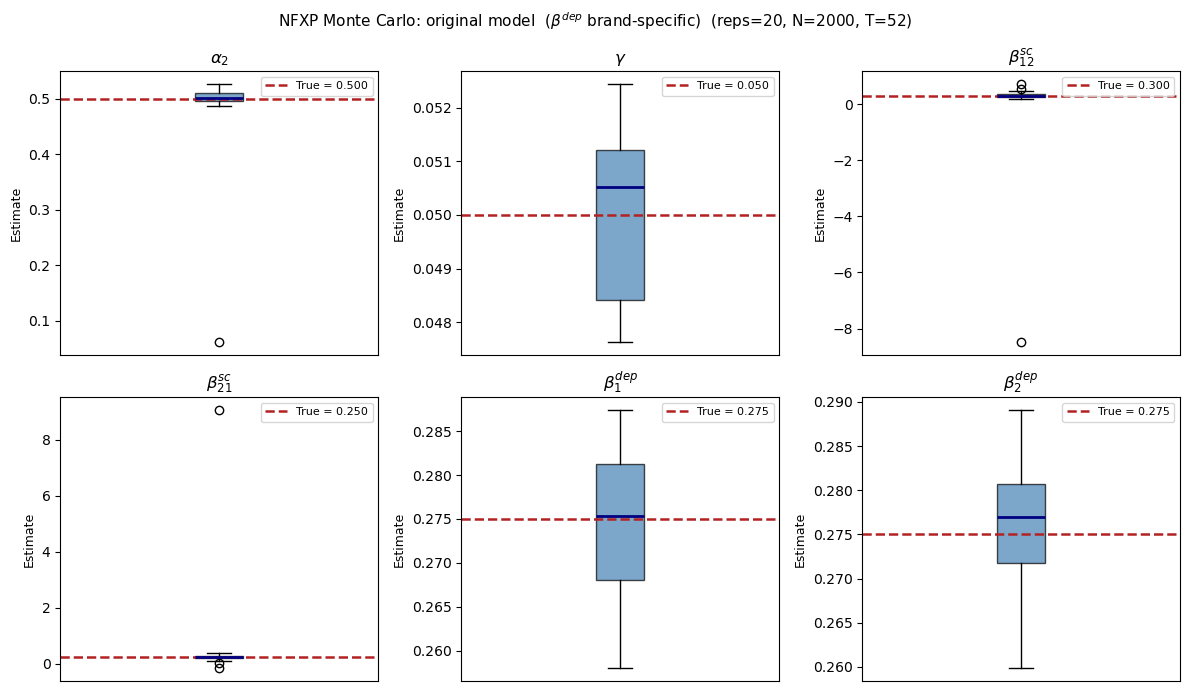

In [27]:
# LaTeX labels for each parameter (used in plots)
latex_lbl = {
    "alpha_2":    r"$\alpha_2$",
    "gamma":      r"$\gamma$",
    "beta_sc_12": r"$\beta^{sc}_{12}$",
    "beta_sc_21": r"$\beta^{sc}_{21}$",
    "beta_dep_1": r"$\beta^{dep}_1$",
    "beta_dep_2": r"$\beta^{dep}_2$",
}

fig, axes = plt.subplots(2, 3, figsize=(12, 7))
axes = axes.flatten()

for ax, (i, name) in zip(axes, enumerate(PARAM_NAMES)):
    est    = results[results["param"] == name]["estimate"].to_numpy()
    true_v = THETA_TRUE[i]
    # Box shows distribution of MC estimates; dashed line marks true value
    ax.boxplot(est, vert=True, patch_artist=True,
               boxprops=dict(facecolor="steelblue", alpha=0.7),
               medianprops=dict(color="navy", linewidth=2))
    ax.axhline(true_v, color="firebrick", lw=1.8, ls="--",
               label=f"True = {true_v:.3f}")
    ax.set_title(latex_lbl.get(name, name), fontsize=12)
    ax.set_ylabel("Estimate", fontsize=9)
    ax.legend(fontsize=8)
    ax.xaxis.set_major_locator(mticker.NullLocator())

fig.suptitle(
    r"NFXP Monte Carlo: original model  ($\beta^{dep}$ brand-specific)"
    f"  (reps={MC_REPS}, N={N}, T={T})",
    fontsize=11,
)
plt.tight_layout()
plt.savefig("nfxp_mc_boxplots_original.pdf", bbox_inches="tight")
plt.show()

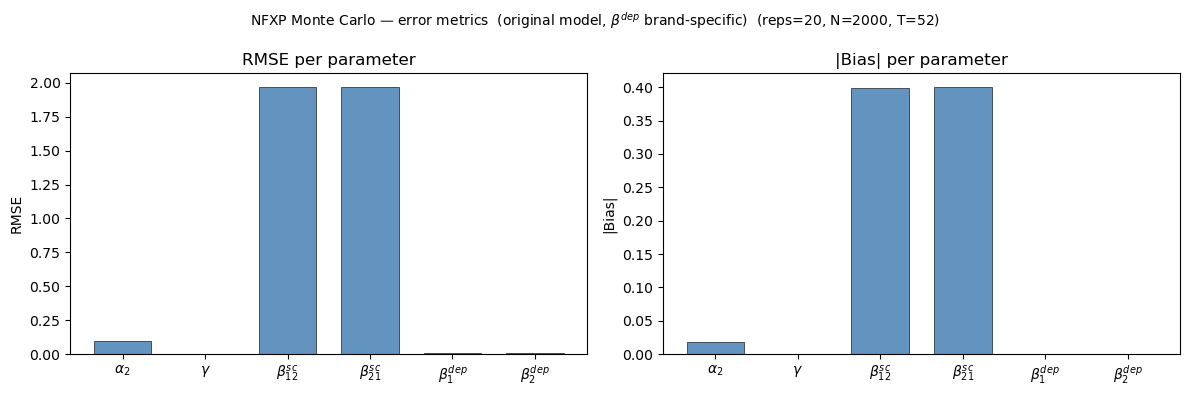

In [28]:
# Bias and RMSE bar chart — summarizes estimation accuracy across parameters
labels   = [latex_lbl.get(n, n) for n in PARAM_NAMES]
bias_abs = [abs(summary.loc[summary["param"] == n, "bias"].values[0]) for n in PARAM_NAMES]
rmse_v   = [summary.loc[summary["param"] == n, "rmse"].values[0]      for n in PARAM_NAMES]

x = np.arange(len(PARAM_NAMES))
w = 0.35

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, vals, ylabel, title in [
    (axes[0], rmse_v,   "RMSE",   "RMSE per parameter"),
    (axes[1], bias_abs, "|Bias|", "|Bias| per parameter"),
]:
    ax.bar(x, vals, 2 * w, color="steelblue", alpha=0.85, edgecolor="black", lw=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=10)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.axhline(0, color="black", lw=0.5)

fig.suptitle(
    r"NFXP Monte Carlo — error metrics  (original model, $\beta^{dep}$ brand-specific)"
    f"  (reps={MC_REPS}, N={N}, T={T})",
    fontsize=10,
)
plt.tight_layout()
plt.savefig("nfxp_mc_bias_rmse_original.pdf", bbox_inches="tight")
plt.show()